<a href="https://colab.research.google.com/github/popojinny/UROP/blob/main/%EB%A7%89%EB%8C%80%EA%B7%B8%EB%9E%98%ED%94%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

uploaded = files.upload()

print("업로드된 파일:")
for filename in uploaded.keys():
    print(filename)

Saving 2000-2007.csv to 2000-2007 (1).csv
업로드된 파일:
2000-2007 (1).csv


In [3]:
import os
print(os.listdir())

['.config', '2016-2020.csv', '2000-2007 (1).csv', '2013-2015.csv', '2008-2012.csv', '2000-2007.csv', '2021-2025.csv', 'sample_data']


In [5]:
filename = list(uploaded.keys())[0]

# Write the uploaded content to a temporary file
with open(filename, 'wb') as f:
    f.write(uploaded[filename])

# Read the file using pd.read_csv (assuming it's a CSV based on content)
df = pd.read_csv(filename)

print(df.head())
print()
print("열 이름:")
print(df.columns.tolist())

   topic  document_count                          topic_label  \
0     -1             129                              Outlier   
1      0             175  care / caregivers / family / burden   
2      1             162      brain / spect / cerebral / left   
3      2             162      test / mmse / dementia / korean   
4      3             138     induced / extract / cell / cells   

                                      topic_keywords  is_outlier  \
0                                                NaN        True   
1  care, caregivers, family, burden, elderly, ser...       False   
2  brain, spect, cerebral, left, mri, patients, d...       False   
3  test, mmse, dementia, korean, age, patients, c...       False   
4  induced, extract, cell, cells, water, alzheime...       False   

                    분야  
0                  NaN  
1             가족돌봄자 부담  
2                뇌영상분석  
3              인지선별검사   
4  천연물 추출물 항치매효과(동물실험)  

열 이름:
['topic', 'document_count', 'topic_label', 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# --------------------------------------------------
# ① 기간 이름
# --------------------------------------------------

periods = [
    "P0(~08)",
    "P1(08~12)",
    "P2(12~16)",
    "P3(16~21)",
    "P4(21~25)"
]

# Helper to extract the corresponding period index from filename
def get_period_index_from_filename(filename):
    # Corrected regex: r'(\d{4})-(\d{4})' to match YYYY-YYYY pattern
    match = re.search(r'(\d{4})-(\d{4})', filename)
    if match:
        start_year = int(match.group(1))
        if 2000 <= start_year <= 2007:
            return 0 # P0(~08)
        elif 2008 <= start_year <= 2012:
            return 1 # P1(08~12)
        elif 2013 <= start_year <= 2015: # Filename 2013-2015.csv fits P2(12~16) period roughly
            return 2 # P2(12~16)
        elif 2016 <= start_year <= 2020:
            return 3 # P3(16~21)
        elif 2021 <= start_year <= 2025:
            return 4 # P4(21~25)
    return -1 # No match

# --------------------------------------------------
# ② 업로드된 파일 (현재 디렉토리의 모든 CSV 파일) 가져오기
# --------------------------------------------------

# Corrected regex: r'\d{4}-\d{4}' to match YYYY-YYYY pattern anywhere in filename
candidate_files = [f for f in os.listdir('.') if f.endswith('.csv') and re.search(r'\d{4}-\d{4}', f)]
candidate_files.sort() # Sort for consistent processing, especially if duplicates like ' (1)' exist

print("처리할 CSV 파일:")
for f in candidate_files:
    print(f)

# --------------------------------------------------
# ③ 분야별 데이터를 기간별로 집계하여 저장할 임시 구조
# --------------------------------------------------

# This will store aggregated data for each period
period_aggregated_data = {period: pd.DataFrame(columns=["분야", "document_count"]) for period in periods}

for filename in candidate_files:
    period_idx = get_period_index_from_filename(filename)
    if period_idx == -1:
        print(f"Skipping {filename}: Does not match any defined period.")
        continue

    current_period_name = periods[period_idx]

    try:
        # Read the CSV file directly from disk
        df_temp = pd.read_csv(filename)
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        continue

    # Filter relevant columns and aggregate by '분야'
    if "분야" in df_temp.columns and "document_count" in df_temp.columns:
        df_processed = df_temp[["분야", "document_count"]].groupby("분야", as_index=False)["document_count"].sum()

        # Merge with existing data for this period (if multiple files for one period, e.g., '2000-2007.csv' and '2000-2007 (1).csv')
        if not period_aggregated_data[current_period_name].empty:
            period_aggregated_data[current_period_name] = pd.concat([period_aggregated_data[current_period_name], df_processed]).groupby("분야", as_index=False)["document_count"].sum()
        else:
            period_aggregated_data[current_period_name] = df_processed
    else:
        print(f"Skipping {filename}: Missing '분야' or 'document_count' column.")


# --------------------------------------------------
# ④ 분야 목록 만들기 (모든 기간에 걸친 고유 분야)
# --------------------------------------------------

all_categories_set = set()
for df_agg in period_aggregated_data.values():
    if not df_agg.empty:
        all_categories_set.update(df_agg["분야"].unique())
categories = sorted(list(all_categories_set))

print("분야:")
print(categories)


# --------------------------------------------------
# ⑤ 기간 × 분야 형태의 최종 표 만들기
# --------------------------------------------------

data = pd.DataFrame(0, index=categories, columns=periods)

for period_name, df_agg in period_aggregated_data.items():
    if not df_agg.empty:
        for _, row in df_agg.iterrows():
            category = row["분야"]
            count = row["document_count"]
            if category in data.index:
                data.loc[category, period_name] = count

print(data)

처리할 CSV 파일:
2000-2007 (1).csv
2000-2007.csv
2008-2012.csv
2013-2015.csv
2016-2020.csv
2021-2025.csv
분야:
['VR 활용 재활', '가족돌봄자 부담', '구강건강과 연하기능', '국가치매관리정책', '뇌영상분석', '디지털, 스마트기기 활용', '문학작품 속 치매 서사', '비알츠하이머형 치매', '비약물적 중재', '성년후견제도와 법적 권리', '아밀로이드 PET 영상 연구', '알츠하이머병 바이오마커와 유전연구', '알츠하이머병과 MCI 임상진단연구', '영양상태와 식이', '운동프로그램의 효과', '원예치료 프로그램', '인공지능 기반 치매예측모델', '인지기능 및 언어기능 저하', '인지기능과 우울', '인지선별검사', '인지선별검사 ', '인지훈련 프로그램', '작업치료 프로그램', '장기요양보험과 성년후견제도', '천연물 추출물 항치매효과(동물실험)', '치매 위험요인', '치매노인 시설의 환경', '치매노인 요양시설 환경', '치매돌봄인력 교육', '치매인식, 태도', '치매정책과 장기요양서비스', '코로나19와 치매환자의 사망위험', '텍스트마이닝과 네트워크분석 방법론 연구', '한의학적 치료']
                       P0(~08)  P1(08~12)  P2(12~16)  P3(16~21)  P4(21~25)
VR 활용 재활                     0          0          0         21         29
가족돌봄자 부담                   350        100         79        103         64
구강건강과 연하기능                   0          0          0         43         34
국가치매관리정책                     0          0          0          0         40
뇌영상분석  

In [11]:
# 열별 합계
column_totals = data.sum(axis=0)

# 각 기간에서 차지하는 비율(%)
percentage = data.div(column_totals, axis=1) * 100

print(percentage.round(1))

                       P0(~08)  P1(08~12)  P2(12~16)  P3(16~21)  P4(21~25)
VR 활용 재활                   0.0        0.0        0.0        1.7        2.3
가족돌봄자 부담                  21.7       13.4       16.1        8.5        5.0
구강건강과 연하기능                 0.0        0.0        0.0        3.5        2.7
국가치매관리정책                   0.0        0.0        0.0        0.0        3.2
뇌영상분석                     20.0        0.0       11.8        2.2        0.0
디지털, 스마트기기 활용              0.0        0.0        0.0        3.2        0.0
문학작품 속 치매 서사               0.0        0.0        0.0        4.9        4.4
비알츠하이머형 치매                 0.0        0.0        0.0        2.4        0.0
비약물적 중재                    6.3        7.8        0.0        3.5        5.2
성년후견제도와 법적 권리              0.0        0.0        0.0        0.0        3.8
아밀로이드 PET 영상 연구            0.0        0.0        0.0        4.1        0.0
알츠하이머병 바이오마커와 유전연구         0.0        0.0        4.7        0.0        3.5
알츠하이머병과 MCI 임상진단연구       

폰트 'NanumGothic'가 Matplotlib에 성공적으로 설정되었습니다.


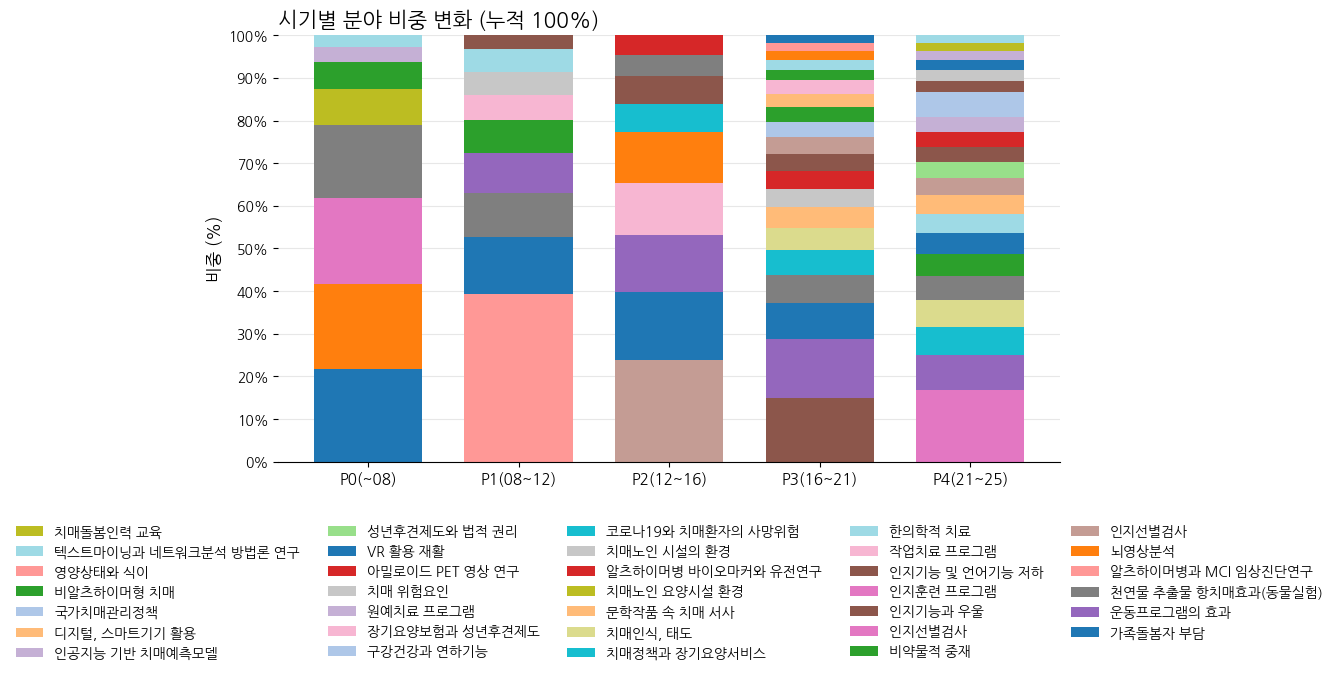

In [25]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import numpy as np

# --------------------------------------------------
# 한글 폰트 설정
# --------------------------------------------------

# Nanum 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

# 시스템 폰트 캐시 업데이트 (Colab 환경에서 중요)
# 이 명령은 시스템 폰트 캐시를 업데이트하지만, Matplotlib의 내부 캐시와는 별개입니다.
!fc-cache -fv > /dev/null

# Matplotlib의 폰트 캐시 삭제
# ~/.cache/matplotlib 경로의 모든 내용을 강제로 삭제하여 Matplotlib가 폰트 목록을 다시 빌드하도록 유도합니다.
!rm -rf ~/.cache/matplotlib

# Matplotlib와 font_manager를 다시 임포트하여 새로운 폰트 정보를 로드하도록 유도
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Matplotlib 폰트 설정
# 설치된 Nanum 폰트 중에서 가장 일반적으로 사용되는 'NanumGothic'을 명시적으로 설정 시도
font_name = 'NanumGothic' # 사용할 폰트의 이름
nanum_font_dir = '/usr/share/fonts/truetype/nanum/'
nanum_gothic_path = os.path.join(nanum_font_dir, 'NanumGothic.ttf') # 가장 흔한 파일명

font_set_successfully = False

# 1. NanumGothic.ttf 파일을 직접 찾아 추가 시도
if os.path.exists(nanum_gothic_path):
    try:
        # 폰트 매니저에 폰트 추가 (폰트 파일 경로 직접 지정)
        fm.fontManager.addfont(nanum_gothic_path)
        # Matplotlib의 font.family 설정을 추가된 폰트의 이름으로 지정
        plt.rcParams['font.family'] = font_name
        plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
        print(f"폰트 '{font_name}'가 Matplotlib에 성공적으로 설정되었습니다.")
        font_set_successfully = True
    except Exception as e:
        print(f"오류: 폰트 '{nanum_gothic_path}' 추가 중 문제 발생: {e}")

if not font_set_successfully:
    # 2. NanumGothic.ttf가 없으면, 다른 Nanum 폰트 파일을 찾아서 적용 시도
    print(f"'{nanum_gothic_path}'를 찾을 수 없거나 추가에 실패했습니다. 다른 Nanum 폰트 탐색 중...")
    for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
        try:
            prop = fm.FontProperties(fname=font_path)
            if 'Nanum' in prop.name:
                # 폰트 매니저에 폰트 추가
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = prop.name
                plt.rcParams['axes.unicode_minus'] = False
                print(f"폰트 '{prop.name}'가 Matplotlib에 성공적으로 설정되었습니다.")
                font_set_successfully = True
                break
        except Exception as e:
            # 폰트 파일이 손상되었거나 읽을 수 없는 경우 무시
            pass

if not font_set_successfully:
    print("오류: 'Nanum'이 포함된 폰트를 찾을 수 없습니다. 런타임을 재시작한 후 다시 시도해 보세요.")
    print("혹은 `!ls /usr/share/fonts/truetype/nanum` 명령어로 설치된 나눔 폰트 목록을 확인해 보세요.")


# --------------------------------------------------
# 그래프
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(periods)) # periods는 이미 정의됨 (예: P0, P1, 등)

# --------------------------------------------------
# 일관된 카테고리 색상 맵 정의.
# 모든 고유 카테고리를 알파벳순으로 정렬하여 색상 맵을 생성합니다.
# 이는 '가족돌봄자 부담'이 어떤 막대에 있든 항상 같은 색상을 갖도록 보장합니다.
all_unique_categories = sorted(percentage.index.tolist())
colors = plt.cm.tab20(np.linspace(0, 1, len(all_unique_categories)))
colors_map = {category: color for category, color in zip(all_unique_categories, colors)}
# --------------------------------------------------

# 범례를 위한 (핸들, 라벨) 쌍을 저장할 딕셔너리
legend_elements_for_sorting = {} # 고유한 핸들과 라벨을 저장하여 최종 정렬에 사용

# 각 기간(열)을 반복하여 개별 누적 막대 생성
for i, period_name in enumerate(periods):
    # 현재 기간의 데이터를 가져와 백분율 기준으로 내림차순 정렬 (가장 큰 값이 바닥에 오도록)
    # 0%인 카테고리는 필터링하여 정렬 및 플로팅을 깔끔하게 유지
    period_data_sorted = percentage[period_name][percentage[period_name] > 0].sort_values(ascending=False)

    # 현재 막대의 스태킹을 위한 바닥 초기화
    current_bottom = 0

    # 현재 기간의 정렬된 순서대로 각 카테고리 플롯
    for category_name, value in period_data_sorted.items():
        bar_segment = ax.bar(
            x[i], # 현재 기간 막대의 x-좌표
            value,
            bottom=current_bottom,
            label=category_name, # 범례를 위해 수집될 라벨
            color=colors_map.get(category_name, 'grey'), # 매핑된 색상 사용, 없으면 회색 기본값
            width=0.72
        )
        current_bottom += value

        # 범례를 위해 이 카테고리의 대표 핸들 저장
        # 범례에 카테고리당 하나의 핸들만 저장되도록 보장
        if category_name not in legend_elements_for_sorting:
            legend_elements_for_sorting[category_name] = bar_segment # BarContainer 저장

# 범례를 위한 핸들과 라벨 준비
# 범례는 전체 기간에 걸친 총 백분율을 기준으로 오름차순으로 정렬합니다 (전체적으로 가장 작은 값이 먼저 오도록).
# `total_percentage_per_category`는 이미 PYAv-3GQ20OU에서 생성되었다고 가정합니다.
# 만약 없으면, 여기에 `total_percentage_per_category = percentage.sum(axis=1)` 추가
# percentage는 vjIrSIZk3WTt 셀에서 생성된 변수입니다.
total_percentage_per_category_sorted_for_legend = percentage.sum(axis=1).sort_values(ascending=True)

sorted_legend_labels = total_percentage_per_category_sorted_for_legend.index.tolist()

# `sorted_legend_labels`를 필터링하여 실제로 그래프에 나타난 카테고리(즉, `legend_elements_for_sorting`에 있는 카테고리)만 포함
final_legend_labels = [label for label in sorted_legend_labels if label in legend_elements_for_sorting]
final_legend_handles = [legend_elements_for_sorting[label][0] for label in final_legend_labels] # BarContainer의 첫 번째 패치 접근

# --------------------------------------------------
# 축 설정
# --------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=11)

ax.set_ylim(0, 100)

ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.set_ylabel("비중 (%)", fontsize=12)

ax.set_title(
    "시기별 분야 비중 변화 (누적 100%)",
    fontsize=15,
    fontweight="bold",
    loc="left"
)


# --------------------------------------------------
# 격자
# --------------------------------------------------

ax.grid(
    axis="y",
    linestyle="-",
    alpha=0.3
)

ax.set_axisbelow(True)


# --------------------------------------------------
# 테두리 제거
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# --------------------------------------------------
# 범례
# --------------------------------------------------

ax.legend(
    final_legend_handles, final_legend_labels, # 명시적으로 정렬된 핸들과 라벨 사용
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
    ncol=5,
    frameon=False
)


plt.tight_layout()

plt.show()